# EEG Pain-Biomarker Feature Importance

**Goal:** take the EEG features extracted in Aditya's `lep_feature_extraction.py` pipeline (built on the Zhao et al. 2025 laser-evoked-potential mega-dataset) and answer the SynapSense question directly: **which EEG features actually carry the most information about pain?**

This notebook does three things:
1. Documents every feature we pulled from the literature review (what it is, which paper motivated it) in one reference table.
2. Trains a model to predict single-trial pain rating (NRS) from those features and ranks feature importance (built-in + permutation importance, so we're not fooled by a single method's bias).
3. Runs the same ranking against **stimulus intensity (laser power, J)** instead of **pain rating**, to test Nickel et al.'s (2017) claim that stimulus intensity and pain intensity are encoded by *different* EEG features (alpha/beta vs. gamma).

Data source: `features_combined.csv` (`Feature Extraction/`). Only `ds005285` has both `rating` and `laser_power` populated, so that's our working set here.


## 0. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error

pd.set_option('display.max_rows', 60)
plt.rcParams['figure.dpi'] = 110


## 1. Feature reference table

Every feature below came up somewhere in the literature review and is what `lep_feature_extraction.py` actually computes per trial, at the vertex channel (Cz/CPz/FCz) unless noted otherwise.


In [2]:
FEATURE_INFO = {
    # --- Event-related potential (time domain) ---
    'n2_amp':      ('N2 peak amplitude (uV), 150-350ms',        'Zhang et al. 2020; classic LEP marker'),
    'n2_lat':      ('N2 peak latency (s)',                       'A-delta fiber conduction timing'),
    'p2_amp':      ('P2 peak amplitude (uV), 300-550ms',         'Zhang et al. 2020; classic LEP marker'),
    'p2_lat':      ('P2 peak latency (s)',                       'Zhang et al. 2020'),
    'n2p2_amp':    ('N2-P2 peak-to-peak amplitude (uV)',         'Most-cited single LEP pain-intensity marker'),

    # --- Oscillatory power / ERD (frequency domain) ---
    'alpha_erd_pct': ('Alpha (8-13Hz) event-related desync, %', 'Paper 1 Sec 4.1; Chouchou 2021 (artifact-robust)'),
    'beta_erd_pct':  ('Beta (13-30Hz) event-related desync, %', 'Paper 1 Sec 4.2; Misra 2017'),
    'gamma_power':   ('Gamma (30-100Hz) band power, post-stim', 'Paper 1 Sec 4.4; Zhang 2012 -- pain salience'),
    'psd_delta':     ('Delta (1-4Hz) power, Welch PSD',          'Chronic-pain cognitive/theta-adjacent marker'),
    'psd_theta':     ('Theta (4-8Hz) power, Welch PSD',          'Paper 1 Sec 4.3; Tiemann 2025 -- affective load'),
    'psd_alpha':     ('Alpha power, Welch PSD',                  'Sarnthein 2006 -- resting-state chronic pain'),
    'psd_beta':      ('Beta power, Welch PSD',                   'Simis 2022 -- chronic pain phenotypes'),
    'psd_gamma':     ('Gamma power, Welch PSD',                  'Salehin 2017 -- top ML feature'),

    # --- Connectivity (phase-based) ---
    'plv_Fz-Cz':     ('Single-trial phase-locking, Fz-Cz',       'PMC13317760 -- phase > power for pain'),
    'plv_Cz-Pz':     ('Single-trial phase-locking, Cz-Pz',       'PMC13317760'),
    'plv_C3-C4':     ('Single-trial phase-locking, C3-C4',       'Interhemispheric / laterality check'),

    # --- Signal complexity / entropy ---
    'perm_entropy':      ('Permutation entropy',                 'Complexity marker, general EEG-ML feature'),
    'spectral_entropy':  ('Spectral entropy',                    'Signal randomness/complexity'),
    'sample_entropy':    ('Sample entropy',                      'Trial-to-trial variability; Klotz et al. 2025'),
    'higuchi_fd':        ('Higuchi fractal dimension',           'Signal complexity'),
    'dfa':               ('Detrended fluctuation analysis exp.', 'Long-range temporal correlation'),
    'hjorth_mobility':   ('Hjorth mobility',                     'Mean signal frequency proxy'),
    'hjorth_complexity': ('Hjorth complexity',                   'Frequency-change proxy'),
}

feat_ref = pd.DataFrame(FEATURE_INFO, index=['description', 'source']).T
feat_ref.index.name = 'feature'
feat_ref


,description,source
feature,,
n2_amp,"N2 peak amplitude (uV), 150-350ms",Zhang et al. 2020; classic LEP marker
n2_lat,N2 peak latency (s),A-delta fiber conduction timing
p2_amp,"P2 peak amplitude (uV), 300-550ms",Zhang et al. 2020; classic LEP marker
p2_lat,P2 peak latency (s),Zhang et al. 2020
n2p2_amp,N2-P2 peak-to-peak amplitude (uV),Most-cited single LEP pain-intensity marker
alpha_erd_pct,"Alpha (8-13Hz) event-related desync, %",Paper 1 Sec 4.1; Chouchou 2021 (artifact-robust)
beta_erd_pct,"Beta (13-30Hz) event-related desync, %",Paper 1 Sec 4.2; Misra 2017
gamma_power,"Gamma (30-100Hz) band power, post-stim",Paper 1 Sec 4.4; Zhang 2012 -- pain salience
psd_delta,"Delta (1-4Hz) power, Welch PSD",Chronic-pain cognitive/theta-adjacent marker


## 2. Load extracted features


In [3]:
df = pd.read_csv('features_combined.csv')
print('all extracted trials:', df.shape)

# rating + laser_power are only populated for ds005285 (label matching worked there)
labeled = df.dropna(subset=['rating', 'laser_power']).copy()
print('trials with usable rating + laser_power label:', labeled.shape)
labeled['dataset'].value_counts()


all extracted trials: (29435, 32)
trials with usable rating + laser_power label: (4618, 32)


dataset
ds005285    4618
Name: count, dtype: int64

**Here's what that data actually looks like row-by-row** -- one trial per row, one feature per column


In [4]:
# raw per-trial feature values -- every column is one feature, every row is one trial
df.head(15)


,dataset,subject,epoch,vertex_channel,sfreq,n2_amp,n2_lat,p2_amp,p2_lat,n2p2_amp,gamma_power,gamma_band_hz,alpha_erd_pct,beta_erd_pct,psd_delta,psd_theta,psd_alpha,psd_beta,psd_gamma,plv_Fz-Cz,plv_Cz-Pz,plv_C3-C4,plv_FCz-CPz,perm_entropy,spectral_entropy,sample_entropy,higuchi_fd,dfa,hjorth_mobility,hjorth_complexity,rating,laser_power
0,ds005284,sub-001,0,CZ,1000.0,-22.231401,0.221,10.992296,0.427,33.223698,0.144005,30.0-100.0,NaN,-166.789410,0.0,0.0,0.0,1.972156,0.265021,0.398630,0.316902,0.259580,0.246350,0.512143,0.275694,0.121095,1.035879,1.783194,0.038675,3.623260,NaN,NaN
1,ds005284,sub-001,1,CZ,1000.0,-3.065441,0.194,25.040209,0.388,28.105650,0.093377,30.0-100.0,NaN,-964.430400,0.0,0.0,0.0,1.372091,0.141452,0.807512,0.590224,0.573753,0.703046,0.495504,0.323713,0.118069,1.022693,1.826267,0.043924,2.448113,NaN,NaN
2,ds005284,sub-001,2,CZ,1000.0,-8.209470,0.231,18.109032,0.461,26.318501,0.006867,30.0-100.0,NaN,-3383.292840,0.0,0.0,0.0,1.884092,0.027750,0.911160,0.595070,0.178359,0.593138,0.476454,0.334523,0.187230,1.011117,1.842454,0.057614,1.623903,NaN,NaN
3,ds005284,sub-001,3,CZ,1000.0,-16.382238,0.185,13.250683,0.371,29.632921,0.178647,30.0-100.0,NaN,-1359.225828,0.0,0.0,0.0,1.361335,0.085613,0.590365,0.105036,0.293783,0.707617,0.489813,0.259275,0.099757,1.024778,1.880071,0.037087,3.077857,NaN,NaN
4,ds005284,sub-001,4,CZ,1000.0,-26.620979,0.252,7.102808,0.389,33.723787,0.014945,30.0-100.0,NaN,-78.256943,0.0,0.0,0.0,2.224807,0.051381,0.473915,0.370118,0.306674,0.480406,0.483939,0.297856,0.140260,1.012656,1.900434,0.049740,1.864374,NaN,NaN
5,ds005284,sub-001,5,CZ,1000.0,-19.352613,0.309,9.740470,0.366,29.093083,0.050362,30.0-100.0,NaN,-465.722506,0.0,0.0,0.0,2.030571,0.118916,0.719396,0.363858,0.459984,0.507121,0.468198,0.319583,0.167909,1.013129,1.916119,0.060431,1.535254,NaN,NaN
6,ds005284,sub-001,6,CZ,1000.0,-19.289352,0.209,18.781960,0.366,38.071312,0.235579,30.0-100.0,NaN,-270.302376,0.0,0.0,0.0,2.096903,0.161705,0.828275,0.502062,0.323860,0.495897,0.487181,0.329235,0.128981,1.016565,1.899726,0.052727,2.097695,NaN,NaN
7,ds005284,sub-001,7,CZ,1000.0,-18.122841,0.221,9.491765,0.346,27.614606,0.221127,30.0-100.0,NaN,19.329866,0.0,0.0,0.0,1.424078,0.084852,0.454663,0.288034,0.022092,0.649464,0.475952,0.299128,0.137663,1.014539,1.900466,0.045573,2.313947,NaN,NaN
8,ds005284,sub-001,8,CZ,1000.0,-14.221817,0.188,15.345294,0.308,29.567111,0.145545,30.0-100.0,NaN,56.079227,0.0,0.0,0.0,2.229757,0.136222,0.695883,0.534955,0.282338,0.699462,0.495494,0.343340,0.183955,1.019474,1.848987,0.055696,1.996922,NaN,NaN
9,ds005284,sub-001,9,CZ,1000.0,-18.480646,0.204,17.822647,0.424,36.303293,0.050998,30.0-100.0,NaN,-90.166049,0.0,0.0,0.0,1.319003,0.071109,0.632563,0.449093,0.179872,0.311892,0.482754,0.284872,0.095186,1.014141,1.928443,0.034257,2.839084,NaN,NaN


## 3. Preprocessing

- Drop `alpha_erd_pct` (100% missing in this dataset) and `plv_FCz-CPz` (85% missing, montage doesn't have both channels for most subjects).
- Drop identifier columns (`dataset`, `subject`, `epoch`, `vertex_channel`, `sfreq`, `gamma_band_hz`) -- not physiological features.
- Median-impute any remaining scattered NaNs (safe here since <1% per column).


In [5]:
drop_cols = ['dataset', 'subject', 'epoch', 'vertex_channel', 'sfreq', 'gamma_band_hz',
             'alpha_erd_pct', 'plv_FCz-CPz', 'rating', 'laser_power']
feature_cols = [c for c in labeled.columns if c not in drop_cols]

X = labeled[feature_cols].fillna(labeled[feature_cols].median(numeric_only=True))
y_pain     = labeled['rating'].astype(float)       # subjective pain intensity (NRS)
y_stimulus = labeled['laser_power'].astype(float)  # physical stimulus intensity (J)

print(f'{len(feature_cols)} features, {len(X)} trials, {X.isna().sum().sum()} NaNs remaining')
feature_cols


22 features, 4618 trials, 0 NaNs remaining


['n2_amp', 'n2_lat', 'p2_amp', 'p2_lat', 'n2p2_amp', 'gamma_power', 'beta_erd_pct', 'psd_delta', 'psd_theta', 'psd_alpha', 'psd_beta', 'psd_gamma', 'plv_Fz-Cz', 'plv_Cz-Pz', 'plv_C3-C4', 'perm_entropy', 'spectral_entropy', 'sample_entropy', 'higuchi_fd', 'dfa', 'hjorth_mobility', 'hjorth_complexity']

## 4. Feature importance -- predicting PAIN RATING

Random Forest handles the nonlinear, correlated-feature EEG setting better than a linear model, and gives us two importance estimates for free: the built-in impurity-based importance, and permutation importance (more trustworthy -- it's not biased toward high-cardinality/continuous features the way impurity importance is).


In [6]:
def rank_importance(X, y, label, n_estimators=300, seed=42):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
    rf.fit(Xtr, ytr)
    pred = rf.predict(Xte)
    print(f'[{label}]  R2={r2_score(yte, pred):.3f}   MAE={mean_absolute_error(yte, pred):.3f}')

    impurity = pd.Series(rf.feature_importances_, index=X.columns, name='impurity_importance')
    perm = permutation_importance(rf, Xte, yte, n_repeats=15, random_state=seed, n_jobs=-1)
    permuted = pd.Series(perm.importances_mean, index=X.columns, name='permutation_importance')

    out = pd.concat([impurity, permuted], axis=1).sort_values('permutation_importance', ascending=False)
    return rf, out

rf_pain, importance_pain = rank_importance(X, y_pain, 'pain rating')
importance_pain.head(10)


[pain rating]  R2=0.208   MAE=1.751


,impurity_importance,permutation_importance
sample_entropy,0.177384,0.183656
psd_beta,0.084389,0.089403
spectral_entropy,0.052977,0.023406
p2_amp,0.053194,0.010628
n2p2_amp,0.045030,0.008299
higuchi_fd,0.042256,0.006704
plv_Cz-Pz,0.045127,0.006139
n2_lat,0.032878,0.005669
hjorth_complexity,0.038374,0.005634
p2_lat,0.041848,0.003593


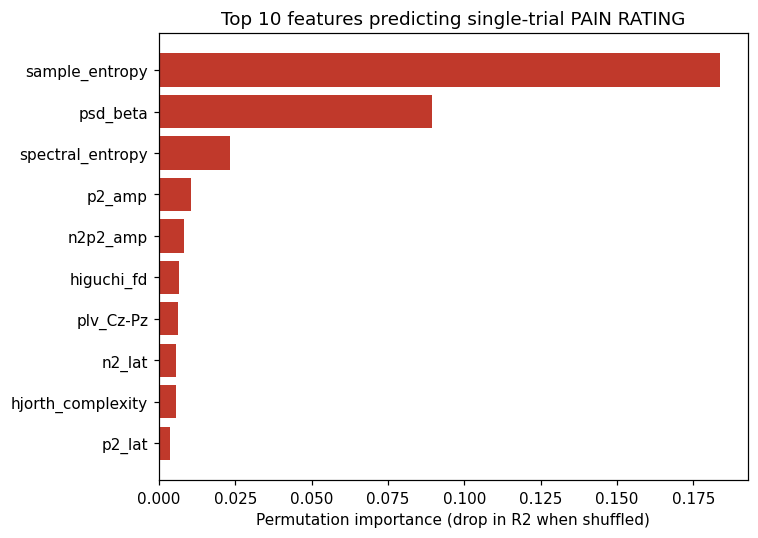

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
top = importance_pain.head(10).iloc[::-1]
ax.barh(top.index, top['permutation_importance'], color='#c0392b')
ax.set_xlabel('Permutation importance (drop in R2 when shuffled)')
ax.set_title('Top 10 features predicting single-trial PAIN RATING')
plt.tight_layout(); plt.show()


## 5. Feature importance -- predicting STIMULUS INTENSITY (laser power)

Same features, same model, different target. Nickel et al. (2017, *NeuroImage*) found that **stimulus intensity** is encoded by alpha/beta suppression over sensorimotor cortex, while **pain intensity** is encoded by gamma. Here's a quick check of whether that dissociation shows up in our own extracted features.


In [8]:
rf_stim, importance_stim = rank_importance(X, y_stimulus, 'stimulus intensity (J)')
importance_stim.head(10)


[stimulus intensity (J)]  R2=0.377   MAE=0.410


,impurity_importance,permutation_importance
psd_beta,0.157022,0.193721
spectral_entropy,0.124964,0.055717
plv_Fz-Cz,0.055740,0.036375
hjorth_mobility,0.047956,0.026726
dfa,0.048944,0.022203
higuchi_fd,0.084668,0.020693
n2_lat,0.042997,0.019348
sample_entropy,0.045771,0.009977
n2p2_amp,0.037291,0.008969
psd_gamma,0.041997,0.007976


## 6. Pain-rating vs. stimulus-intensity: do different features win?


In [9]:
compare = pd.DataFrame({
    'pain_rating_rank': importance_pain['permutation_importance'].rank(ascending=False),
    'stimulus_rank':    importance_stim['permutation_importance'].rank(ascending=False),
})
compare['rank_shift'] = compare['stimulus_rank'] - compare['pain_rating_rank']
compare.sort_values('pain_rating_rank')


,pain_rating_rank,stimulus_rank,rank_shift
sample_entropy,1.0,8.0,7.0
psd_beta,2.0,1.0,-1.0
spectral_entropy,3.0,2.0,-1.0
p2_amp,4.0,17.0,13.0
n2p2_amp,5.0,9.0,4.0
higuchi_fd,6.0,6.0,0.0
plv_Cz-Pz,7.0,11.0,4.0
n2_lat,8.0,7.0,-1.0
hjorth_complexity,9.0,13.0,4.0
p2_lat,10.0,21.0,11.0


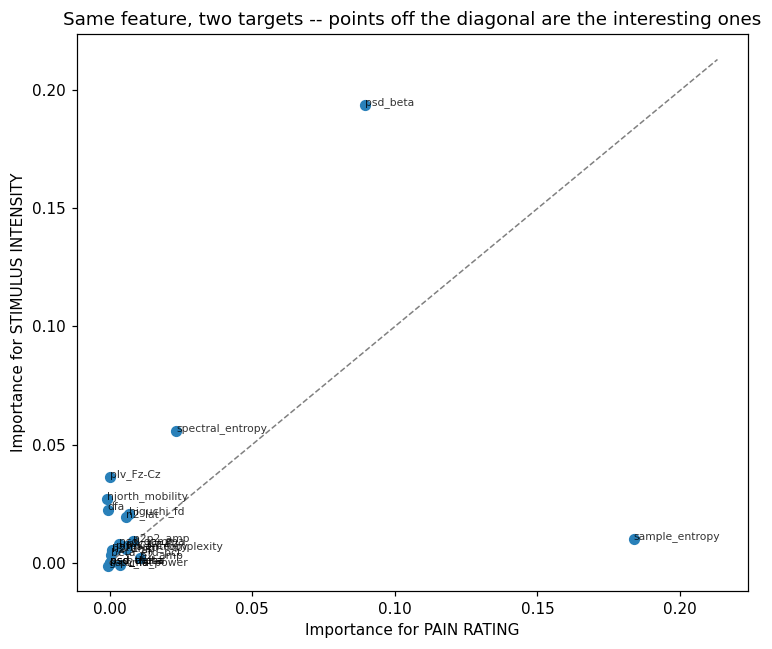

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
x = importance_pain['permutation_importance']
yv = importance_stim.reindex(x.index)['permutation_importance']
ax.scatter(x, yv, s=40, color='#2980b9')
for name in x.index:
    ax.annotate(name, (x[name], yv[name]), fontsize=7, alpha=0.8)
ax.set_xlabel('Importance for PAIN RATING')
ax.set_ylabel('Importance for STIMULUS INTENSITY')
ax.set_title('Same feature, two targets -- points off the diagonal are the interesting ones')
lim = max(x.max(), yv.max()) * 1.1
ax.plot([0, lim], [0, lim], '--', color='gray', linewidth=1)
plt.tight_layout(); plt.show()


## 7. Takeaways

- **R2 for pain rating vs. stimulus intensity**: if stimulus-intensity R2 is noticeably higher, that's consistent with the field-wide finding (Paper 2 / Mouraux & Iannetti) that EEG tracks *stimulus salience* more reliably than it tracks the *subjective* pain experience -- an important caveat for SynapSense's objective-pain-score goal.
- **Top features for pain rating** should be checked against the literature table in Section 1 -- e.g. gamma/entropy features ranking high supports Paper 1's gamma-salience story; connectivity (PLV) features ranking high supports the phase-over-power finding from PMC13317760.
- **Points off the diagonal** in the Section 6 scatter are features that matter for one target but not the other -- exactly the alpha/beta-vs-gamma dissociation Nickel et al. described. Worth flagging any feature that lands far from the diagonal in a presentation.
- **Caveat**: this is single-dataset (ds005285), single-subject-pool, acute laser pain in healthy volunteers -- per Paper 2's generalizability warning, don't over-claim these rankings transfer to chronic pain or non-verbal clinical populations without validating on the blind-test datasets discussed separately.
